In [1]:
import pandas as pd 
import numpy as np 
from sklearn import metrics 
from sklearn.naive_bayes import GaussianNB 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [22]:
wine_dataset = pd.read_csv("WineQT.csv")

In [97]:
wine_dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,good_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0


In [24]:
wine_dataset.shape

(1143, 13)

In [25]:
wine_dataset.size

14859

In [9]:
wine_dataset.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


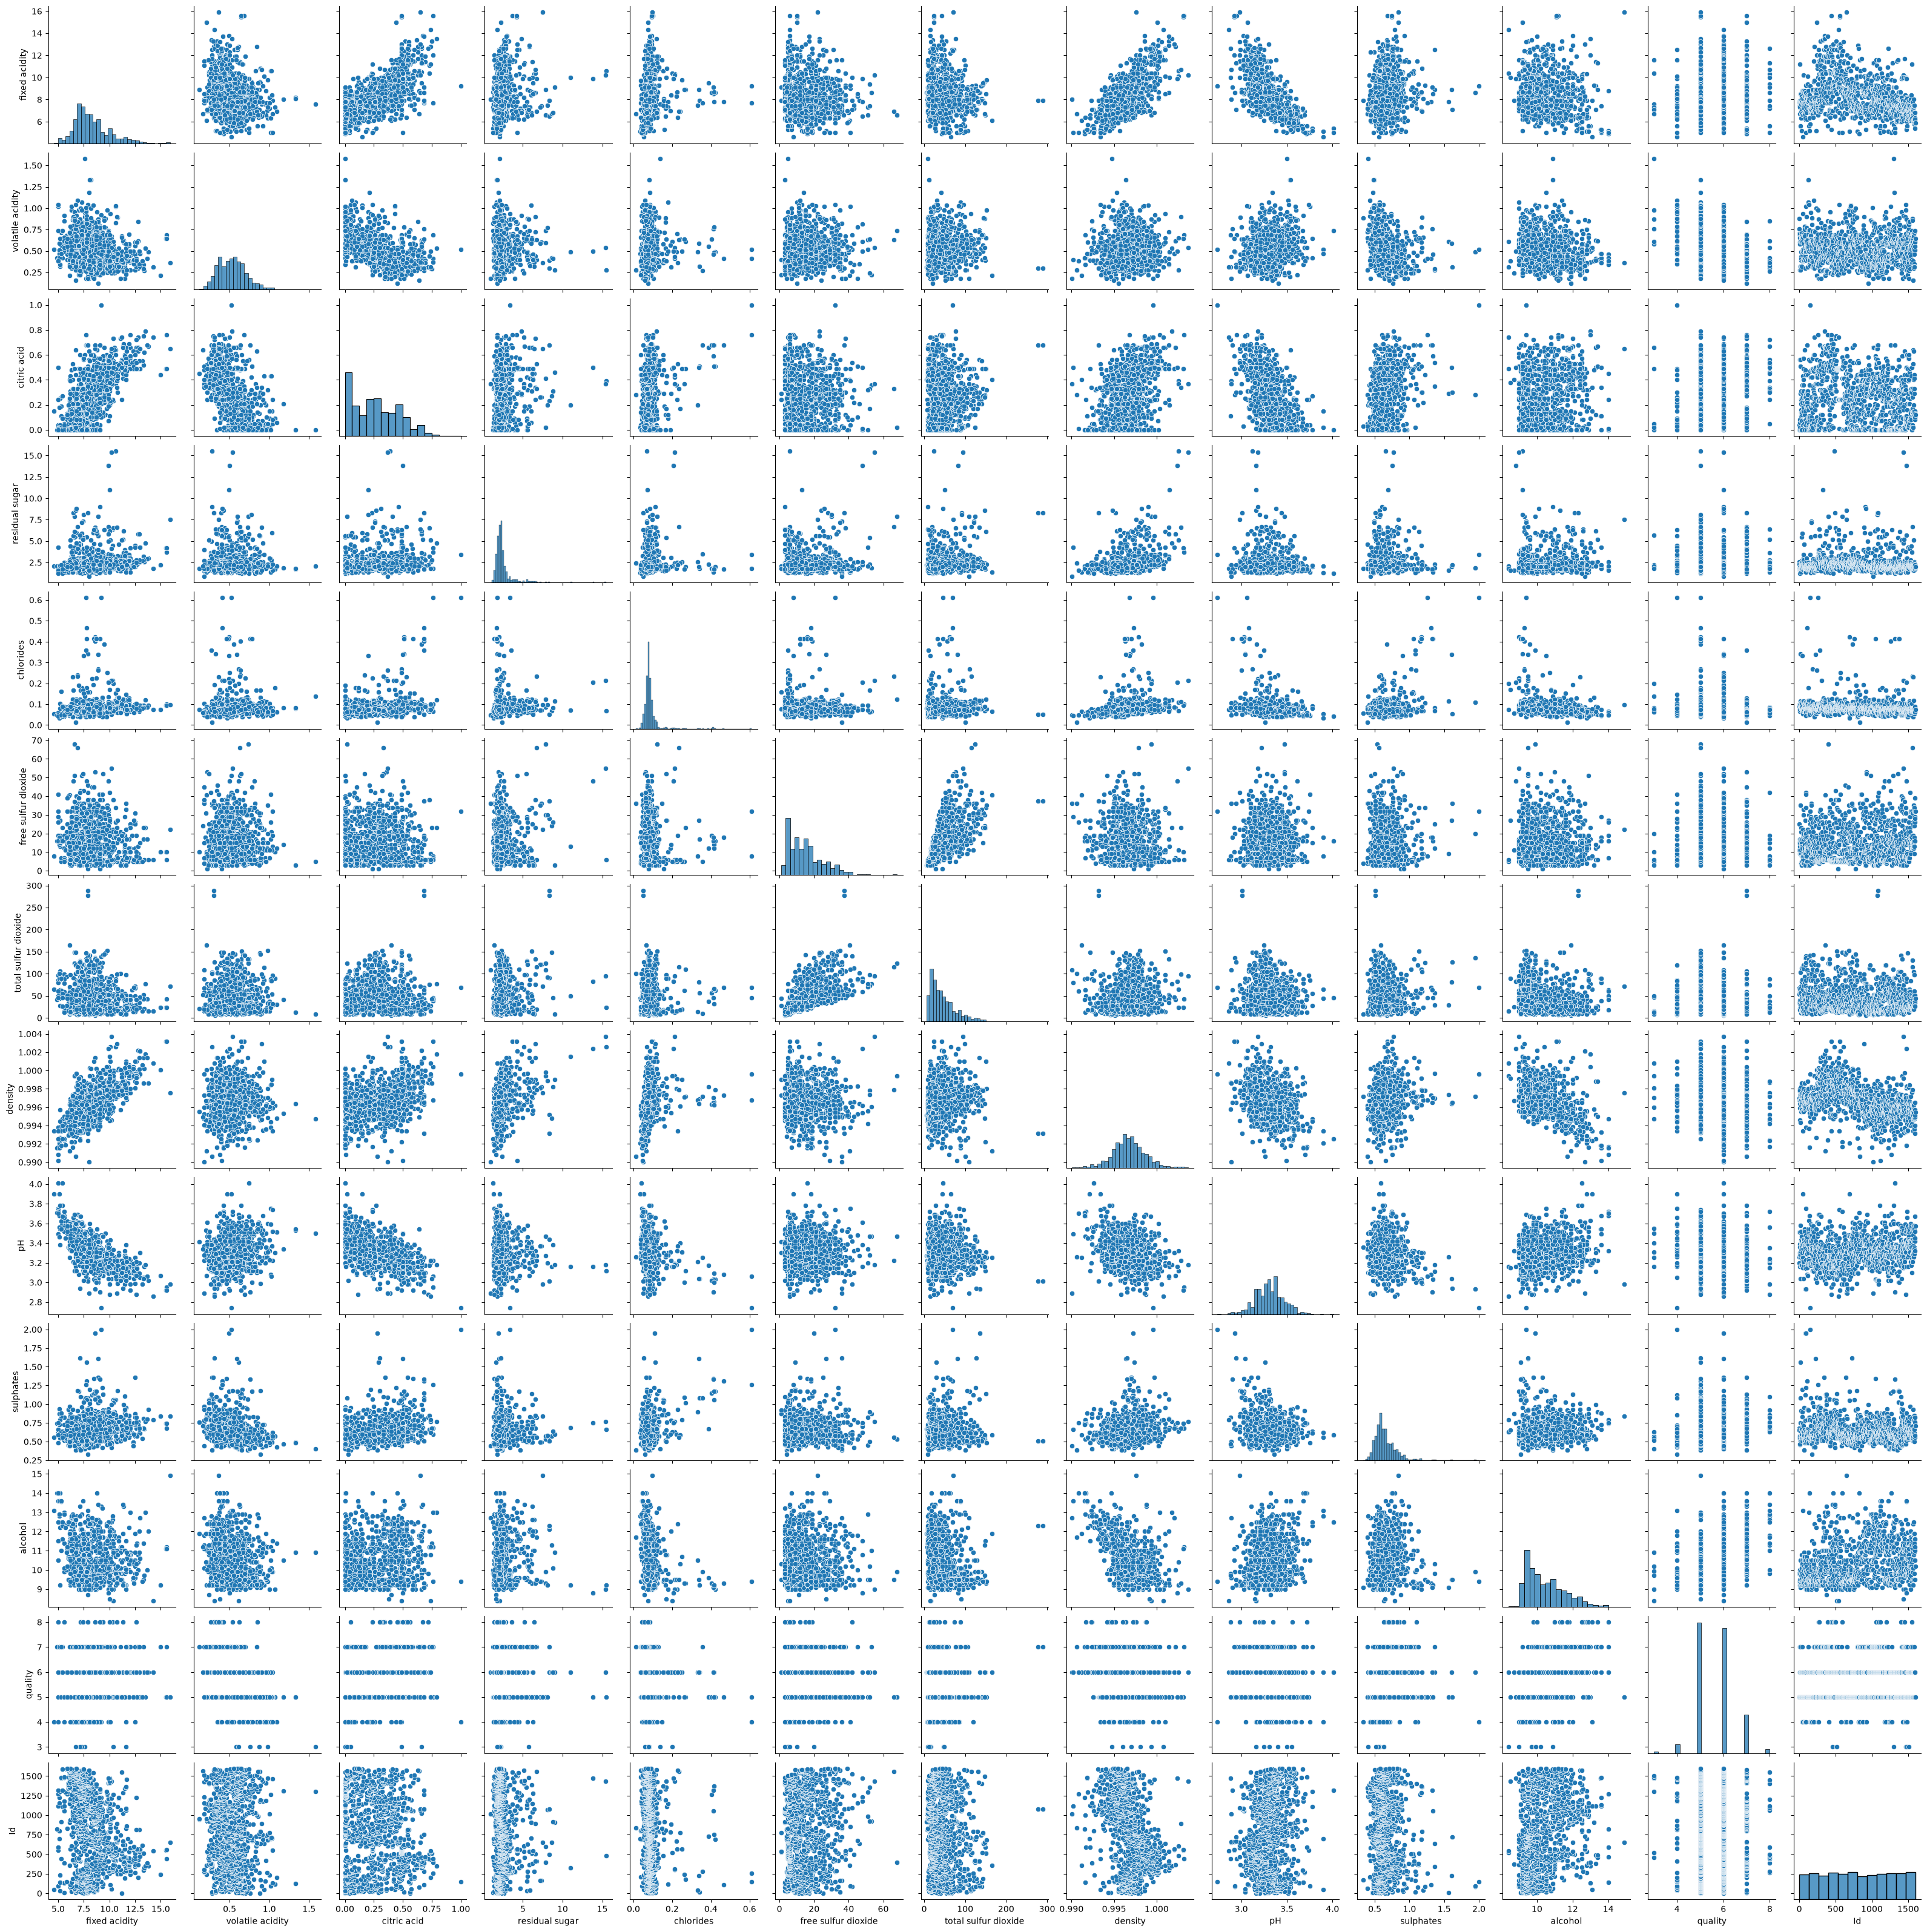

In [26]:
sns.pairplot(wine_dataset)
plt.show()

In [27]:
wine_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [28]:
wine_dataset.duplicated().sum()

np.int64(0)

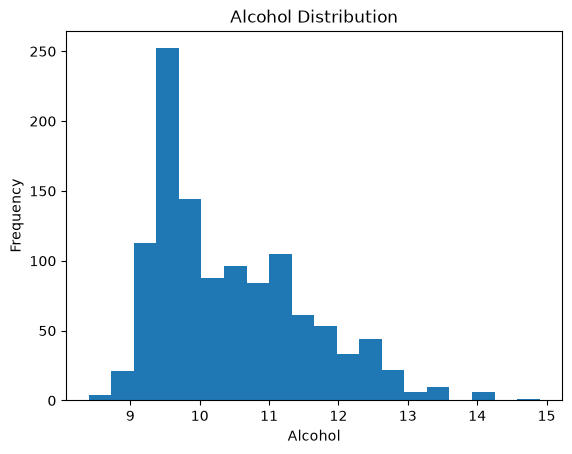

In [29]:
plt.hist(wine_dataset["alcohol"], bins=20) 

plt.title("Alcohol Distribution")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")

plt.show()

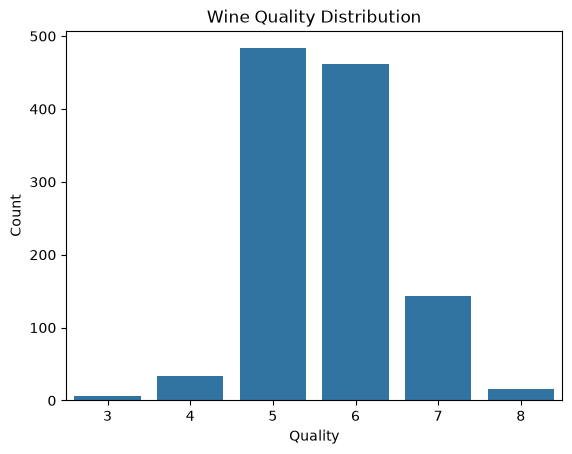

In [30]:
sns.countplot(x="quality", data=wine)

plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")

plt.show()

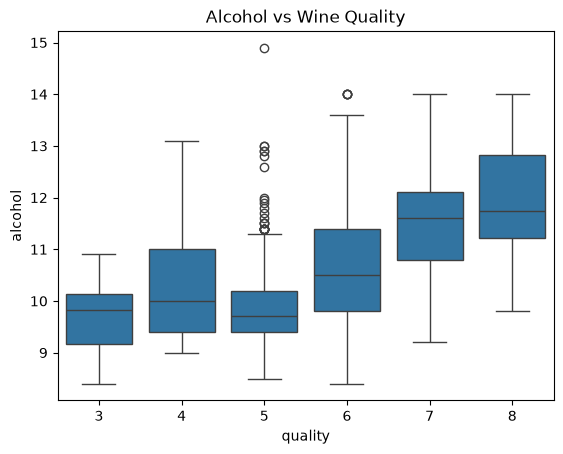

In [32]:
sns.boxplot(x="quality", y="alcohol", data=wine)

plt.title("Alcohol vs Wine Quality")

plt.show()

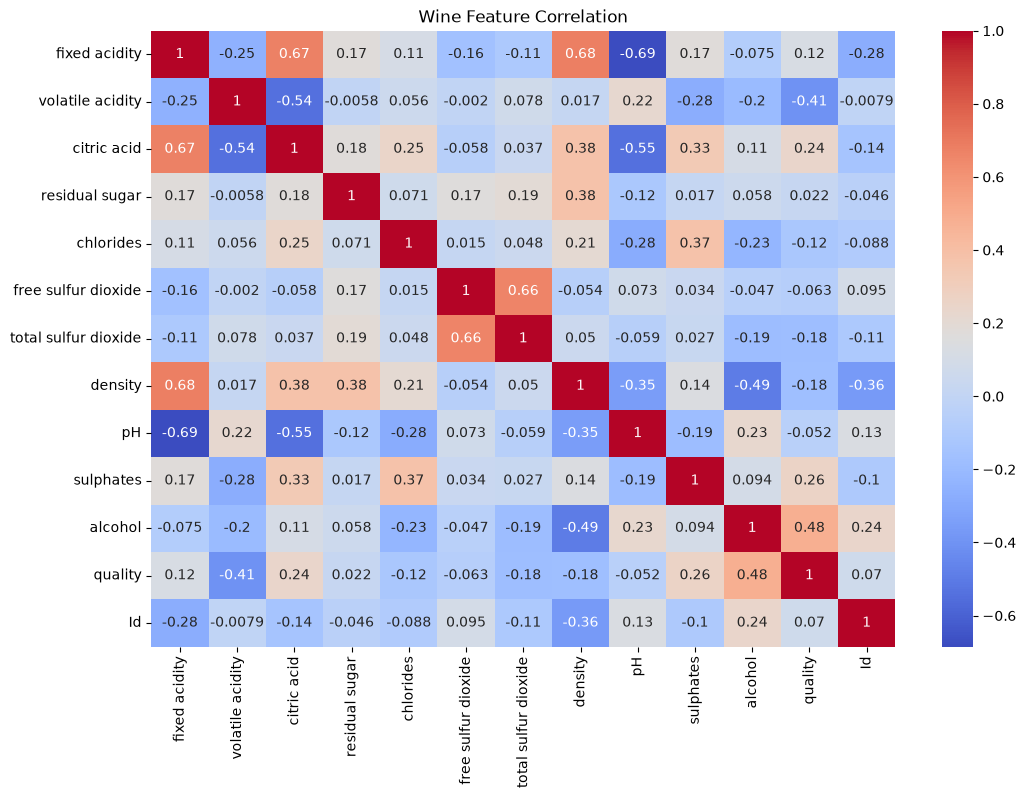

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(wine_dataset.corr(), annot=True, cmap="coolwarm")

plt.title("Wine Feature Correlation")

plt.show()

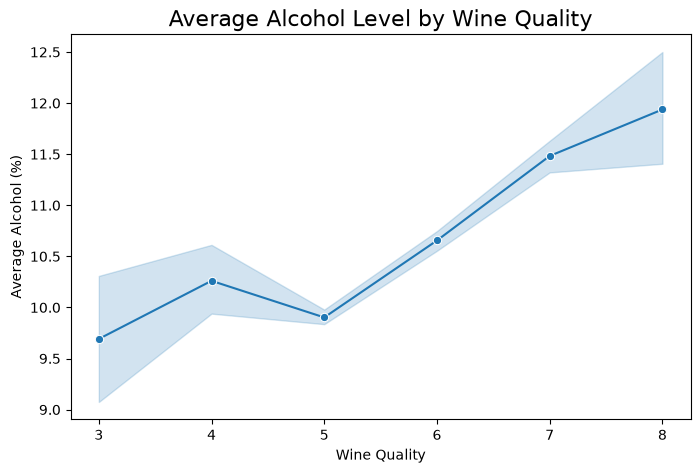

In [50]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x="quality", 
    y="alcohol",
    data=wine,
    marker="o"
) 

plt.title("Average Alcohol Level by Wine Quality", fontsize=16)
plt.xlabel("Wine Quality")
plt.ylabel("Average Alcohol (%)")

plt.show()

In [51]:
wine_dataset["good_quality"] = (wine_dataset["quality"] >=7).astype(int) 

 

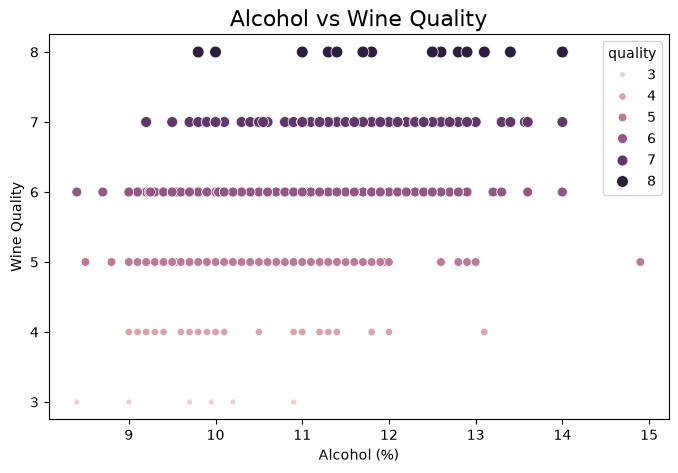

In [54]:
plt.figure(figsize=(8,5))

sns.scatterplot( 
    x="alcohol",
    y="quality",
    data=wine_dataset, 
    hue="quality", 
    size="quality"
) 

plt.title("Alcohol vs Wine Quality", fontsize=16)
plt.xlabel("Alcohol (%)")
plt.ylabel("Wine Quality")

plt.show()

In [61]:
from sklearn.model_selection import train_test_split

In [67]:
x = wine_dataset.drop(["quality", "good_quality"], axis=1)
y = wine_dataset["good_quality"]

In [68]:
x.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,4


In [69]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: good_quality, dtype: int64

In [70]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42

)    

In [71]:
x_train.shape

(914, 12)

In [74]:
x_test.shape

(229, 12)

In [75]:
y_train.shape

(914,)

In [76]:
y_test.shape

(229,)

In [77]:
model = GaussianNB()

In [78]:
model.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[783.,131.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.86,0.14]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.0002159
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['fixed acidity','volatile acidity','citric acid',...,'sulphates', 'alcohol','Id']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 12)","[[ 8.19, 0.55, 0.25,..., 0.64, 10.26,811.26], [ 8.66, 0.4 , 0.38,..., 0.75, 11.51,841.46]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 12)","[[ 2.59, 0.03, 0.04,..., 0.03, 0.96,223237.96], [ 4.38, 0.02, 0.04,..., 0.02, 1. ,170920. ]]"


In [79]:
y_pred = model.predict(x_test)

In [81]:
y_pred[:10]

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [82]:
from sklearn.metrics import accuracy_score

In [83]:
from sklearn.metrics import confusion_matrix

In [84]:
from sklearn.metrics import classification_report

In [85]:
accuracy = accuracy_score(y_test, y_pred)

print("accuracy:", accuracy)

accuracy: 0.8296943231441049


In [86]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[168  33]
 [  6  22]]


In [87]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.84      0.90       201
           1       0.40      0.79      0.53        28

    accuracy                           0.83       229
   macro avg       0.68      0.81      0.71       229
weighted avg       0.90      0.83      0.85       229



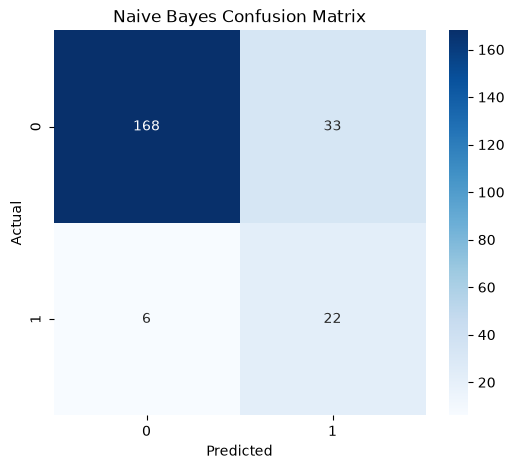

In [92]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True, 
    fmt="d", 
    cmap="Blues"

) 

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()
    